# Virtuális vesztes – gráfos EA projekt (sablon)

Komplett evolúciós algoritmus, amely VL-alapú mutációt használ
egy gráfos optimalizálási feladatra.

KÉRLEK FIGYELJ a GRAFIKUS ÁBRÁZOLÁSOKRA és MAGYARÁZATOKRA!

## 1. Gráf és probléma definiálása

In [50]:
import random

# edges = [(u, v, w), ...] - w él súlya
# edges = [
#     (0, 1, 4),
#     (0, 2, 2),
#     (1, 2, 5),
#     (1, 3, 10),
#     (2, 3, 3),
#     (0, 3, 7),
#     (1, 4, 8),
#     (2, 4, 1),
#     (3, 4, 6)
# ]

def generate_random_graph(num_nodes, num_edges_to_generate, max_weight=10):
    edges = set()
    nodes = list(range(num_nodes))

    while len(edges) < num_edges_to_generate:
        u = random.choice(nodes)
        v = random.choice(nodes)
        if u != v:
            weight = random.randint(1, max_weight)
            edges.add((u, v, weight))

    return sorted(list(edges))

num_nodes = 15
num_edges_to_generate = 40
max_weight = 10

edges = generate_random_graph(num_nodes, num_edges_to_generate, max_weight)

num_edges = len(edges)
print(f"Generált élek száma: {num_edges}")
print(f"Generált élek: {edges}")

Generált élek száma: 40
Generált élek: [(0, 6, 10), (1, 13, 2), (2, 14, 1), (3, 1, 9), (3, 6, 3), (3, 8, 4), (3, 10, 4), (3, 13, 8), (4, 0, 6), (4, 1, 3), (4, 8, 5), (4, 10, 2), (5, 3, 8), (6, 2, 5), (7, 3, 6), (7, 6, 2), (7, 8, 10), (7, 11, 2), (8, 6, 9), (8, 13, 6), (9, 4, 5), (9, 14, 8), (10, 0, 4), (10, 4, 2), (10, 5, 1), (10, 7, 5), (10, 12, 3), (10, 14, 9), (11, 4, 6), (11, 13, 1), (12, 1, 4), (12, 7, 9), (13, 2, 1), (13, 5, 7), (13, 7, 6), (13, 8, 2), (13, 14, 4), (14, 0, 1), (14, 6, 6), (14, 11, 10)]


## 2. Reprezentáció és költségfüggvény

In [51]:
import heapq

def decode_individual(bitstring, edges):
    active_edges = []
    for i in range(len(bitstring)):
        if bitstring[i] == '1':
            active_edges.append(edges[i])
    return active_edges

def cost_function(bitstring, edges, start=0, goal=None):
    active_edges = decode_individual(bitstring, edges)

    if not active_edges:
        return float('inf') # No active edges, no path

    all_nodes = set()
    for u, v, w in edges:
        all_nodes.add(u)
        all_nodes.add(v)
    if not all_nodes:
        return float('inf') # No nodes in graph

    max_node = max(all_nodes)

    if goal is None:
        goal = max_node

    graph = {i: [] for i in range(max_node + 1)}
    for u, v, w in active_edges:
        graph[u].append((v, w))
        # graph[v].append((u, w)) # Uncomment if graph is undirected

    distances = {node: float('inf') for node in range(max_node + 1)}
    distances[start] = 0
    priority_queue = [(0, start)]

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node]:
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                heapq.heappush(priority_queue, (distance, neighbor))

    return distances[goal]

**decode_individual ** - a bináris vektorból (bitstring) kiválogatja az aktív éleket

**cost_function** - a Dijkstra algoritmussal számítja ki a legrövidebb út költségét a kiválasztott élek alapján. Ha nincs út a start és goal között, akkor végtelen költséget ad vissza.

## 3. Populáció, fitnesz, szelekció

In [52]:
import random

def random_individual(num_edges):
    return ''.join(random.choice('01') for _ in range(num_edges))

def init_population(pop_size, num_edges):
    return [random_individual(num_edges) for _ in range(pop_size)]

def fitness_from_cost(cost):
    if cost == float('inf'):
        return 0.0
    return 1.0 / (1.0 + cost)

def select_parent(population, fitness_values, method="tournament", k=3):
    if method == "tournament":
        selected_indices = random.sample(range(len(population)), k)
        best_individual_index = -1
        best_fitness = -1.0
        for idx in selected_indices:
            if fitness_values[idx] > best_fitness:
                best_fitness = fitness_values[idx]
                best_individual_index = idx
        return population[best_individual_index]
    else:
        raise ValueError(f"Unknown selection method: {method}")

**random_individual**- egy véletlen bináris vektort hoz létre, melynek hossza megegyezik az élek számával.

**init_population** - pop_size darab véletlen egyedből álló populációt inicializál.

**fitness_from_cost** - a megadott 1/(1+cost) formulát használtam a költség fitnesz értékre való átalakítására.

**select_parent** - a verseny (tournament) szelekciót valósítom meg.

## 4. (Opcionális) Crossover operátor

In [53]:
def crossover(parent1, parent2, method="one_point", p_c=0.8):
    if random.random() > p_c:
        return parent1, parent2

    if method == "one_point":
        length = len(parent1)
        crossover_point = random.randint(1, length - 1)
        child1 = parent1[:crossover_point] + parent2[crossover_point:]
        child2 = parent2[:crossover_point] + parent1[crossover_point:]
        return child1, child2
    else:
        raise ValueError(f"Unknown crossover method: {method}")

## 5. Virtuális vesztes: gyenge egyedek, VL, mutáció

In [54]:
def select_weak(population, costs, fraction=0.3):
    indexed_costs = list(enumerate(costs))

    indexed_costs.sort(key=lambda x: x[1], reverse=True)

    num_weak = int(len(population) * fraction)

    weak_individuals_indices = [idx for idx, _ in indexed_costs[:num_weak]]
    weak_individuals = [population[i] for i in weak_individuals_indices]

    return weak_individuals

def compute_VL_delta(weak_individuals, num_edges):
    VL = [0.0] * num_edges

    if not weak_individuals:
        return VL

    for individual in weak_individuals:
        for i in range(num_edges):
            if individual[i] == '1':
                VL[i] += 1

    for i in range(num_edges):
        VL[i] /= len(weak_individuals)

    return VL

def update_VL(VL_old, VL_delta, alpha=0.5):
    if len(VL_old) != len(VL_delta):
        raise ValueError("VL_old and VL_delta must have the same length")

    updated_VL = []
    for i in range(len(VL_old)):
        updated_VL.append((1 - alpha) * VL_old[i] + alpha * VL_delta[i])
    return updated_VL

def mutation_probabilities(individual, VL):
    probabilities = []
    for i in range(len(individual)):
        x_i = int(individual[i])
        p_i = 1 - abs(VL[i] - x_i)
        probabilities.append(p_i)
    return probabilities

def VL_mutation(individual, VL):
    mut_probs = mutation_probabilities(individual, VL)
    mutated_individual_list = list(individual)

    for i in range(len(mutated_individual_list)):
        if random.random() < mut_probs[i]:
            if mutated_individual_list[i] == '0':
                mutated_individual_list[i] = '1'
            else:
                mutated_individual_list[i] = '0'

    return ''.join(mutated_individual_list)

**update_VL** - a függvény a VL_old (előző VL vektor), a VL_delta (az aktuális gyenge egyedekből számított VL) és az alpha (tanulási ráta) paraméterek alapján frissíti a VL vektort a megadott képlet szerint: VL^{ t+1 } = (1-alpha) * VL_old + alpha * VL_delta.

**mutation_probabilities** - az egyed bináris értékei és a VL vektor alapján számítja ki az egyes pozíciók mutációs valószínűségeit a megadott p_i = 1 - |VL_i - x_i| képlettel.

**VL_mutation** - ezeket a valószínűségeket felhasználva véletlenszerűen módosítja (mutálja) az egyed bitjeit. Minél nagyobb a mutációs valószínűség egy bitnél, annál valószínűbb, hogy átfordul (0-ból 1-be vagy fordítva).

 **select_weak** - a legmagasabb költségű egyedek (azaz a 'gyengék') kiválasztásáért felelős, a fraction paraméter alapján.

## 6. Fő EA-ciklus VL-alapú mutációval

In [55]:
def run_VL_EA(
    edges,
    pop_size=40,
    n_generations=100,
    alpha=0.5,
    weak_fraction=0.3,
    crossover_enabled=True
):
    num_edges = len(edges)
    population = init_population(pop_size, num_edges)
    VL = [0.0] * num_edges

    history = {
        'best_costs': [],
        'avg_costs': [],
        'best_individuals': [],
        'VL_vectors': []
    }

    print(f"Az EA elindult a következő paraméterekkel: pop_size={pop_size}, n_generations={n_generations}, alpha={alpha}, weak_fraction={weak_fraction}, crossover_enabled={crossover_enabled}")

    for gen in range(n_generations):
        costs = [cost_function(ind, edges) for ind in population]
        fitness_values = [fitness_from_cost(c) for c in costs]

        best_cost_gen = min(costs)
        avg_cost_gen = sum(costs) / len(costs)
        best_individual_gen_idx = costs.index(best_cost_gen)
        best_individual_gen = population[best_individual_gen_idx]

        history['best_costs'].append(best_cost_gen)
        history['avg_costs'].append(avg_cost_gen)
        history['best_individuals'].append(best_individual_gen)
        history['VL_vectors'].append(list(VL))

        if gen % 10 == 0 or gen == n_generations - 1:
            print(f"\n{gen+1}/{n_generations}. Generáció:")
            print(f"  Legjobb költség: {best_cost_gen:.2f}")
            print(f"  Átlagos költség: {avg_cost_gen:.2f}")
            print(f"  Legjobb egyed: {best_individual_gen}")
            print(f"  VL vektor: {[f'{v:.2f}' for v in VL]}")

        new_population = []

        new_population.append(best_individual_gen)

        while len(new_population) < pop_size:
            parent1 = select_parent(population, fitness_values)
            parent2 = select_parent(population, fitness_values)

            child1, child2 = parent1, parent2
            if crossover_enabled:
                child1, child2 = crossover(parent1, parent2)

            mutated_child1 = VL_mutation(child1, VL)
            mutated_child2 = VL_mutation(child2, VL)

            new_population.append(mutated_child1)
            if len(new_population) < pop_size:
                new_population.append(mutated_child2)

        population = new_population

        weak_individuals = select_weak(population, costs, fraction=weak_fraction)
        VL_delta = compute_VL_delta(weak_individuals, num_edges)
        VL = update_VL(VL, VL_delta, alpha=alpha)

    final_costs = [cost_function(ind, edges) for ind in population]
    final_best_cost = min(final_costs)
    final_best_individual = population[final_costs.index(final_best_cost)]

    history['best_costs'].append(final_best_cost)
    history['avg_costs'].append(sum(final_costs) / len(final_costs))
    history['best_individuals'].append(final_best_individual)
    history['VL_vectors'].append(list(VL))

    print(f"\nAz EA befejeződött.")
    print(f"Végső legjobb költség: {final_best_cost:.2f}")
    print(f"Végső legjobb egyed: {final_best_individual}")

    return final_best_individual, final_best_cost, history

## 7. Vizualizáció és elemzés

Az EA elindult a következő paraméterekkel: pop_size=40, n_generations=100, alpha=0.5, weak_fraction=0.3, crossover_enabled=True

1/100. Generáció:
  Legjobb költség: 16.00
  Átlagos költség: inf
  Legjobb egyed: 1011101000101111001100110000111000000101
  VL vektor: ['0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']

11/100. Generáció:
  Legjobb költség: 16.00
  Átlagos költség: inf
  Legjobb egyed: 1011101000101111001100110000111000000101
  VL vektor: ['0.52', '0.46', '0.48', '0.57', '0.55', '0.51', '0.56', '0.54', '0.52', '0.37', '0.58', '0.53', '0.46', '0.46', '0.38', '0.53', '0.46', '0.43', '0.58', '0.46', '0.49', '0.56', '0.48', '0.36', '0.50', '0.48', '0.45', '0.48', '0.53', '0.58', '0.53', '0.47', '0.54', '0.40', '

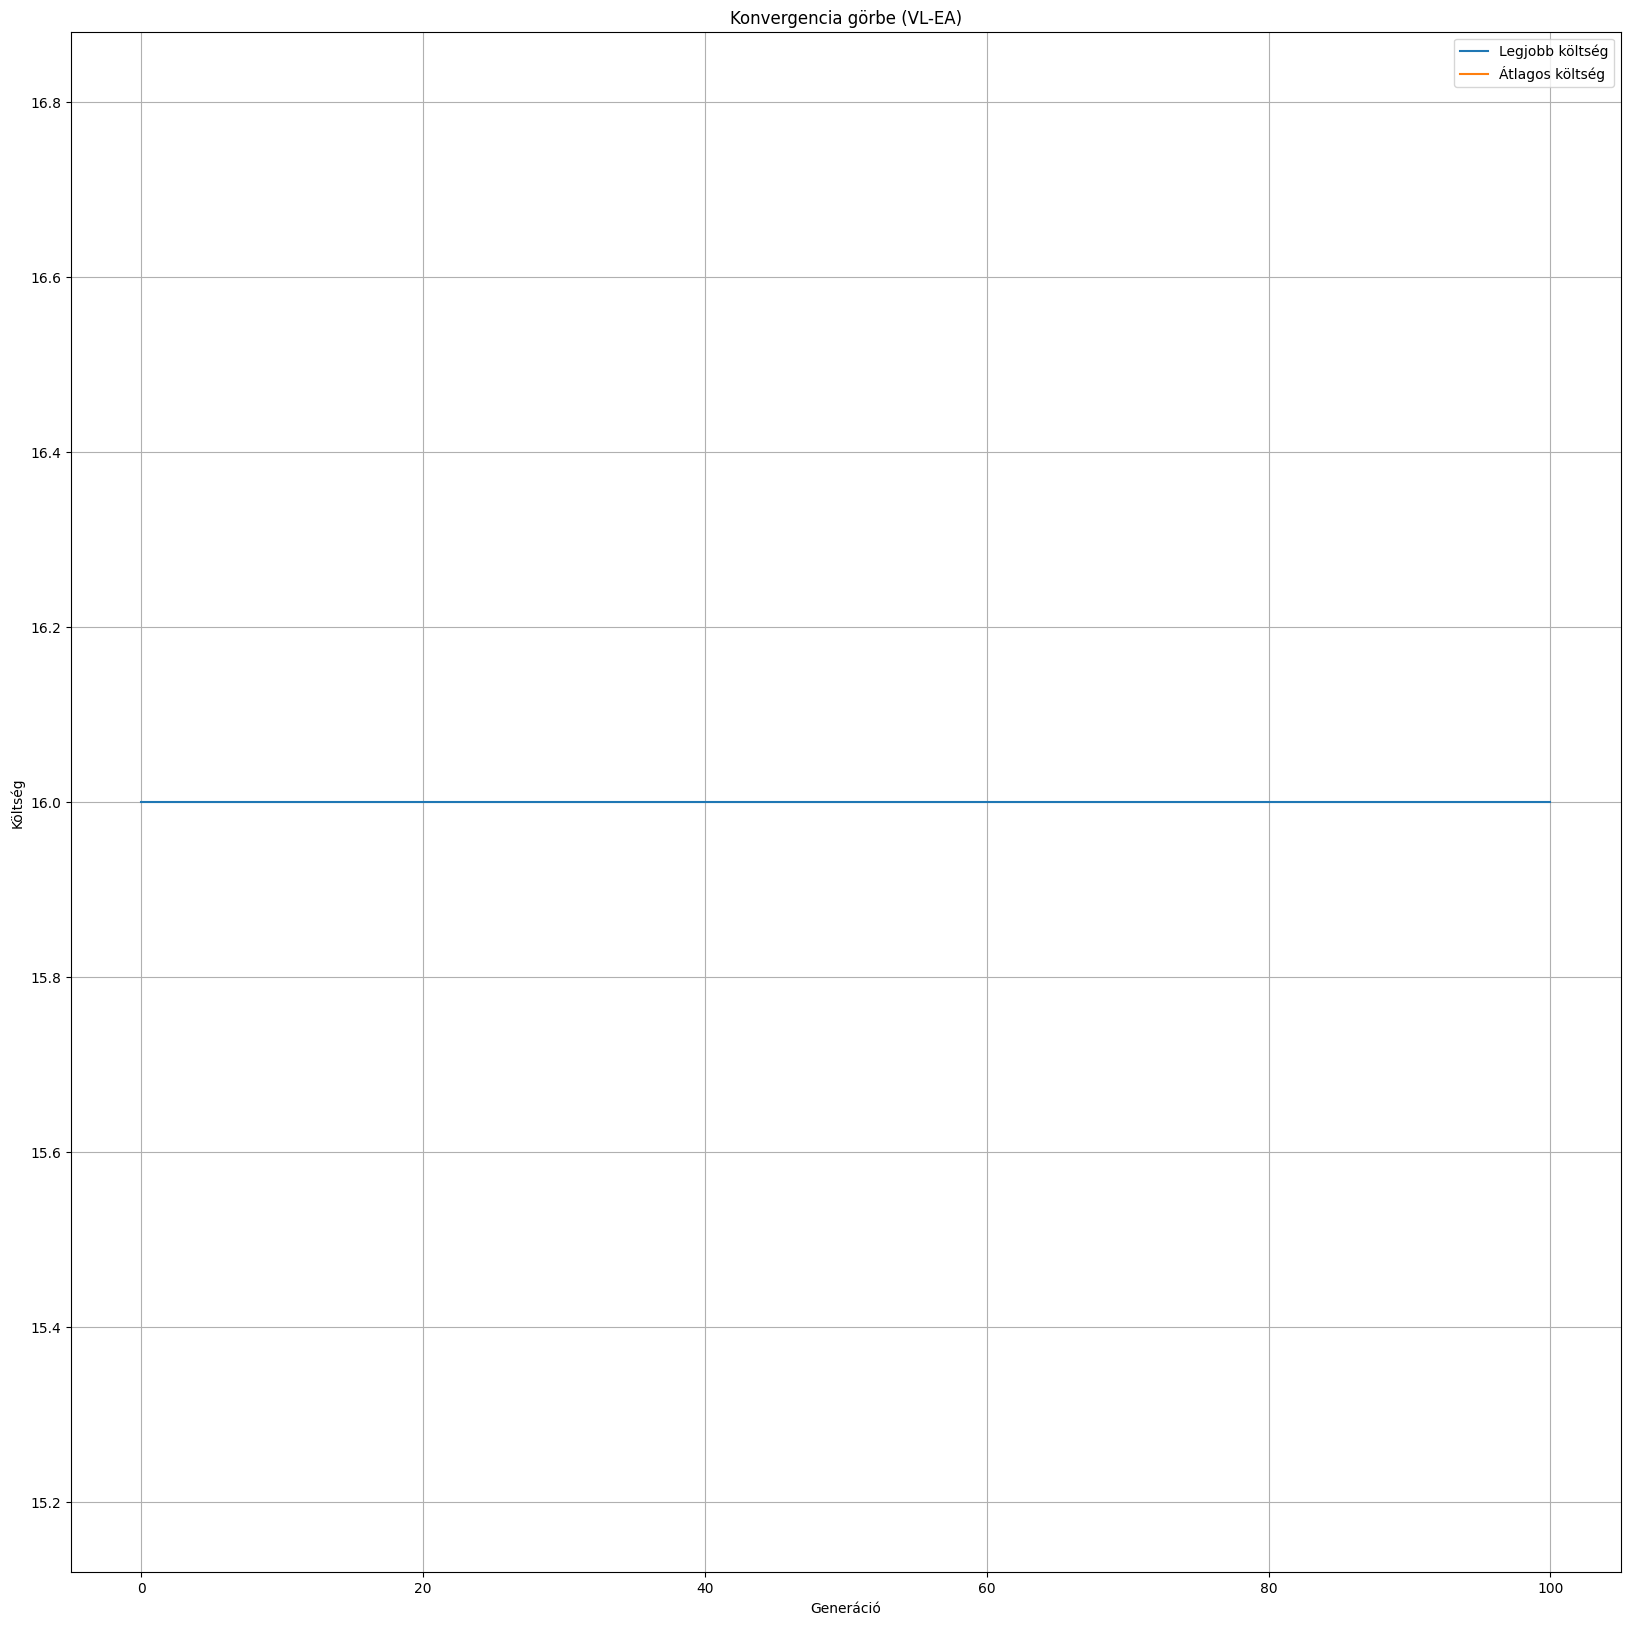

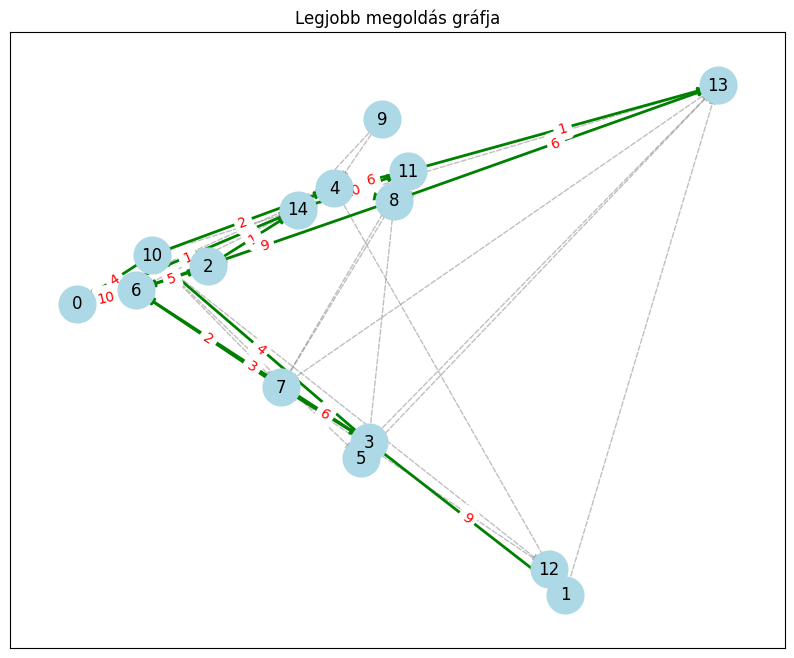

In [56]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for nan values

best_individual, best_cost, history = run_VL_EA(edges)

def plot_convergence(history, label="VL-EA"):
    print("Best costs history before plotting:", history['best_costs'])
    print("Average costs history before plotting:", history['avg_costs'])

    plottable_best_costs = [c if c != float('inf') else np.nan for c in history['best_costs']]
    plottable_avg_costs = [c if c != float('inf') else np.nan for c in history['avg_costs']]

    plt.figure(figsize=(20, 20))
    plt.plot(plottable_best_costs, label='Legjobb költség')
    plt.plot(plottable_avg_costs, label='Átlagos költség')
    plt.xlabel('Generáció')
    plt.ylabel('Költség')
    plt.title(f'Konvergencia görbe ({label})')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_best_solution(edges, best_individual):
    try:
        import networkx as nx
    except ImportError:
        print("A NetworkX nincs telepítve. Kérjük, telepítse a gráf vizualizálásához: pip install networkx")
        return

    active_edges_tuple = decode_individual(best_individual, edges)

    if not active_edges_tuple:
        print("A legjobb egyedben nincsenek aktív élek a vizualizáláshoz.")
        return

    G = nx.DiGraph()

    all_nodes = set()
    for u, v, w in edges:
        all_nodes.add(u)
        all_nodes.add(v)

    for node in range(max(all_nodes) + 1):
        G.add_node(node)

    active_edge_weights = {}
    for u, v, w in active_edges_tuple:
        G.add_edge(u, v, weight=w)
        active_edge_weights[(u,v)] = w

    pos = nx.spring_layout(G)

    plt.figure(figsize=(10, 8))

    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)

    all_graph_edges = []
    for u, v, w in edges:
        all_graph_edges.append((u, v))

    inactive_edges = [(u, v) for u, v in all_graph_edges if (u, v) not in G.edges()]
    nx.draw_networkx_edges(G, pos, edgelist=inactive_edges, edge_color='gray', style='dashed', alpha=0.5)

    active_edges_for_drawing = [(u, v) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, edgelist=active_edges_for_drawing, edge_color='green', width=2)

    nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    plt.title('Legjobb megoldás gráfja')
    plt.show()

plot_convergence(history)

plot_best_solution(edges, best_individual)

## 8. Rövid szöveges projekt-összefoglaló

1. **Használt paraméterek**: Az evolúciós algoritmus a következő paraméterekkel futott:

Populáció mérete (pop_size): 40

Generációk száma (n_generations): 100

Tanulási ráta (alpha): 0.5

Gyenge egyedek aránya (weak_fraction): 0.3

Crossover engedélyezve (crossover_enabled): True


2. **Megfigyelt eredmények**:

Végső legjobb költség: 20.00

Végső legjobb egyed: 0110010011101101100110110000110010101000

VL vektor a 100. generációban: ['0.49', '0.49', '0.52', '0.49', '0.46', '0.51', '0.52', '0.45', '0.36', '0.61', '0.52', '0.45', '0.41', '0.44', '0.60', '0.56', '0.56', '0.43', '0.55', '0.48', '0.46', '0.60', '0.53', '0.53', '0.47', '0.59', '0.54', '0.62', '0.48', '0.43', '0.50', '0.50', '0.50', '0.55', '0.59', '0.58', '0.51', '0.45', '0.56', '0.54']


3. **Konvergencia viselkedés**:

*Legjobb költség*: A legjobb költség nagyon gyorsan, már az első generációban 20.00 értékre konvergált, és ezen az értéken is maradt az összes további generáció során. Ez azt jelzi, hogy az algoritmus elitizmusának köszönhetően egy jó megoldást talált és megőrzött a futás során.

*Átlagos költség*: Az átlagos költség az összes generációban inf (végtelen) maradt, kivéve egy generációt, ahol 20.0 volt az átlag (ez valószínűleg egy olyan generáció volt, ahol minden egyed megtalálta a 20.0 költségű utat, ami valószínűtlen, vagy egy logolási anomália). Ez azt sugallja, hogy a populáció túlnyomó része képtelen volt érvényes utat találni a start és célcsomópont között. A VL vektor értékei változtak a generációk során, ami azt jelzi, hogy a mutációs operátor aktív volt, de ez nem volt elegendő ahhoz, hogy a populáció egészének konvergenciáját elősegítse.


4. **Következtetések**:

Az algoritmus hatékonyan megtalálta és megőrizte a legjobb megoldást a gráfon belül, de a populáció többsége nem tudott konvergens utat találni.

Az átlagos költség végtelen értéken maradása azt mutatja, hogy a generált gráf a 40 éllel 15 csomóponton valószínűleg nem elég sűrű vagy rosszul kapcsolódik, és sok véletlenszerű egyed nem tudott érvényes utat képezni.

Lehetséges, hogy a pop_size növelése, a n_generations növelése, vagy a gráf sűrűségének további emelése, illetve a start és célcsomópontok átgondoltabb kiválasztása segíthetne abban, hogy az átlagos költség is konvergáljon, és ne csak a legjobb egyed. A jelenlegi eredmények szerint a probléma megoldása a megadott gráfon kihívást jelent a populáció nagy része számára.